## Predicting Temperature: A Machine Learning Approach

This notebook details a machine learning project focused on predicting temperature (`tempC`) using various weather and atmospheric features from the `weather_pune.csv` dataset. The process involves data preprocessing, exploratory data analysis, feature engineering, and the training and evaluation of multiple regression models. Models are compared using RMSE to determine the most effective approach for accurate temperature forecasting.

## Importing Libraries and Loading the dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV

In [ ]:
df = pd.read_csv('weather_pune.csv')
df.head()

,date_time,maxtempC,mintempC,totalSnow_cm,sunHour,uvIndex,moon_illumination,moonrise,moonset,sunrise,...,WindGustKmph,cloudcover,humidity,precipMM,pressure,tempC,visibility,winddirDegree,windspeedKmph,location
0,11-12-2008 00:00,30,18,0,11.0,6,93,4:33 PM,5:13 AM,6:57 AM,...,10,31,72,0.0,1013,18,10,114,5,pune
1,11-12-2008 01:00,30,18,0,11.0,6,93,4:33 PM,5:13 AM,6:57 AM,...,9,30,72,0.0,1013,19,10,125,4,pune
2,11-12-2008 02:00,30,18,0,11.0,6,93,4:33 PM,5:13 AM,6:57 AM,...,8,29,72,0.0,1013,18,10,136,4,pune
3,11-12-2008 03:00,30,18,0,11.0,6,93,4:33 PM,5:13 AM,6:57 AM,...,8,29,72,0.0,1013,18,10,147,4,pune
4,11-12-2008 04:00,30,18,0,11.0,6,93,4:33 PM,5:13 AM,6:57 AM,...,7,23,68,0.0,1014,20,10,136,4,pune


This cell loads the `weather_pune.csv` dataset into a pandas DataFrame, providing an initial glimpse of the raw data structure and its first few rows.

## Performing EDA

In [ ]:
df.columns

Index(['date_time', 'maxtempC', 'mintempC', 'totalSnow_cm', 'sunHour',
       'uvIndex', 'moon_illumination', 'moonrise', 'moonset', 'sunrise',
       'sunset', 'DewPointC', 'FeelsLikeC', 'HeatIndexC', 'WindChillC',
       'WindGustKmph', 'cloudcover', 'humidity', 'precipMM', 'pressure',
       'tempC', 'visibility', 'winddirDegree', 'windspeedKmph', 'location'],
      dtype='object')

In [ ]:
req_cols = ["totalSnow_cm", "sunHour", "uvIndex", "moon_illumination", "DewPointC", "HeatIndexC", "WindChillC", "WindGustKmph", "cloudcover", "humidity", "precipMM", "pressure", "tempC", "visibility", "winddirDegree", "windspeedKmph"]
df = df[req_cols]

df.head()

,totalSnow_cm,sunHour,uvIndex,moon_illumination,DewPointC,HeatIndexC,WindChillC,WindGustKmph,cloudcover,humidity,precipMM,pressure,tempC,visibility,winddirDegree,windspeedKmph
0,0,11.0,6,93,13,18,18,10,31,72,0.0,1013,18,10,114,5
1,0,11.0,6,93,14,19,19,9,30,72,0.0,1013,19,10,125,4
2,0,11.0,6,93,13,18,18,8,29,72,0.0,1013,18,10,136,4
3,0,11.0,6,93,13,18,18,8,29,72,0.0,1013,18,10,147,4
4,0,11.0,6,93,13,20,20,7,23,68,0.0,1014,20,10,136,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116136 entries, 0 to 116135
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   totalSnow_cm       116136 non-null  int64  
 1   sunHour            116136 non-null  float64
 2   uvIndex            116136 non-null  int64  
 3   moon_illumination  116136 non-null  int64  
 4   DewPointC          116136 non-null  int64  
 5   HeatIndexC         116136 non-null  int64  
 6   WindChillC         116136 non-null  int64  
 7   WindGustKmph       116136 non-null  int64  
 8   cloudcover         116136 non-null  int64  
 9   humidity           116136 non-null  int64  
 10  precipMM           116136 non-null  float64
 11  pressure           116136 non-null  int64  
 12  tempC              116136 non-null  int64  
 13  visibility         116136 non-null  int64  
 14  winddirDegree      116136 non-null  int64  
 15  windspeedKmph      116136 non-null  int64  
dtypes:

This provides a concise summary of the DataFrame, including column data types and non-null counts, confirming that all selected features are numeric and there are no missing values after the initial filtering.

In [ ]:
df.isnull().sum()

,0
totalSnow_cm,0
sunHour,0
uvIndex,0
moon_illumination,0
DewPointC,0
HeatIndexC,0
WindChillC,0
WindGustKmph,0
cloudcover,0
humidity,0


This check explicitly confirms that there are no missing values in any of the selected columns, ensuring the dataset is clean for direct use in correlation analysis and model training.

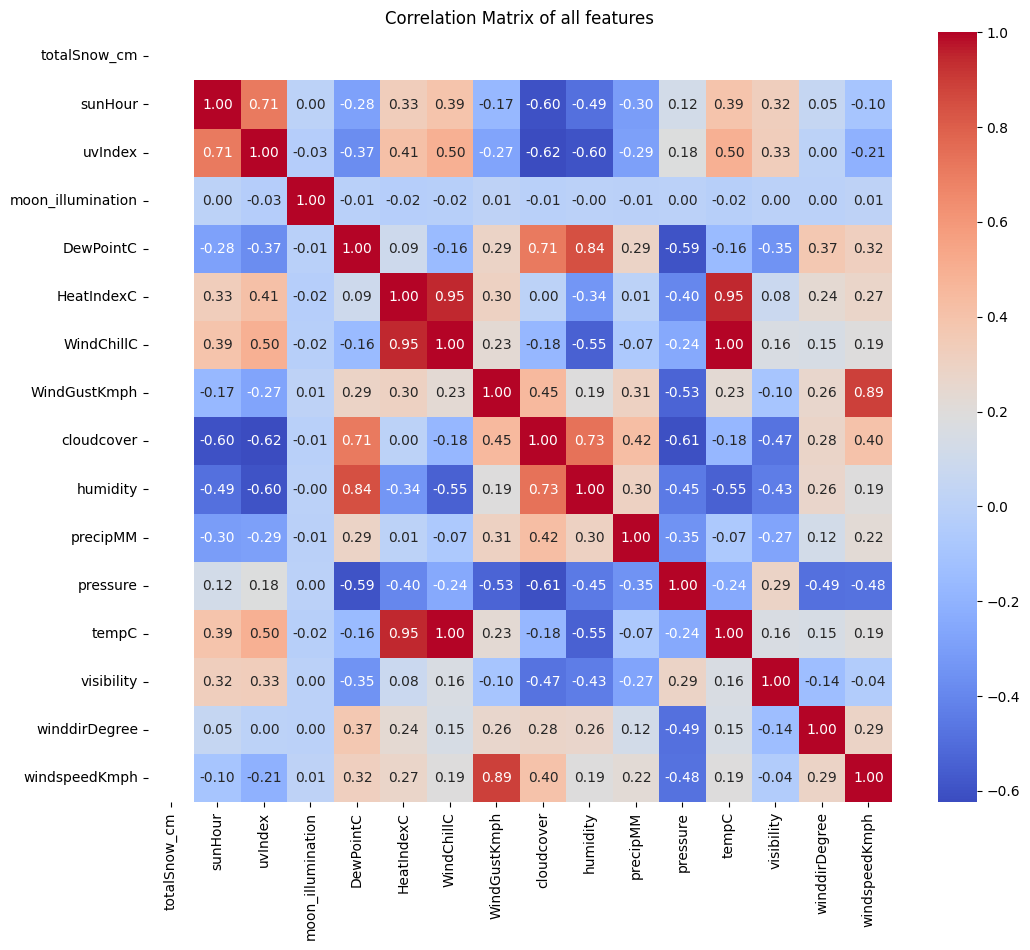

In [ ]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of all features')
plt.show()

This cell computes and visualizes the correlation matrix for all numeric features, offering a comprehensive overview of the linear relationships between variables in the dataset.

In [ ]:
tempC_corr = corr_matrix['tempC'].sort_values(ascending=False)
tempC_corr = tempC_corr.drop('tempC')
display(tempC_corr)

,tempC
WindChillC,0.999976
HeatIndexC,0.948141
uvIndex,0.495740
sunHour,0.393301
WindGustKmph,0.231450
windspeedKmph,0.191092
visibility,0.158122
winddirDegree,0.147275
moon_illumination,-0.019645
precipMM,-0.067562


Based on the `tempC` correlation values, we can identify the most influential features:

**Strong Positive Correlations:**
*   `WindChillC` (0.999974): `WindChillC` shows an extremely strong positive correlation with `tempC`, indicating that as wind chill temperature increases, the actual temperature also increases significantly.
*   `HeatIndexC` (0.946565): This is another very strong positive correlation, indicating that as the heat index increases, the temperature significantly increases.
*   `uvIndex` (0.457942): Higher UV index values are moderately associated with higher temperatures.
*   `sunHour` (0.374908): More sun hours are moderately associated with higher temperatures.

**Strong Negative Correlations:**
*   `humidity` (-0.530333): This is the strongest negative correlation, suggesting that as humidity increases, the temperature tends to decrease.
*   `pressure` (-0.227152): Higher pressure values are moderately associated with lower temperatures.
*   `cloudcover` (-0.182551): More cloud cover is moderately associated with lower temperatures.

`totalSnow_cm` has a NaN correlation, likely due to a lack of variance in the data (e.g., all values are zero or constant), which prevents a meaningful correlation calculation.

In [ ]:
df = df.drop("totalSnow_cm", axis=1)
df.head()

,sunHour,uvIndex,moon_illumination,DewPointC,HeatIndexC,WindChillC,WindGustKmph,cloudcover,humidity,precipMM,pressure,tempC,visibility,winddirDegree,windspeedKmph
0,11.0,6,93,13,18,18,10,31,72,0.0,1013,18,10,114,5
1,11.0,6,93,14,19,19,9,30,72,0.0,1013,19,10,125,4
2,11.0,6,93,13,18,18,8,29,72,0.0,1013,18,10,136,4
3,11.0,6,93,13,18,18,8,29,72,0.0,1013,18,10,147,4
4,11.0,6,93,13,20,20,7,23,68,0.0,1014,20,10,136,4


Since `totalSnow_cm` showed no relation with `tempC`, we can drop this feature from the useful ones

## Visualizations for better understanding

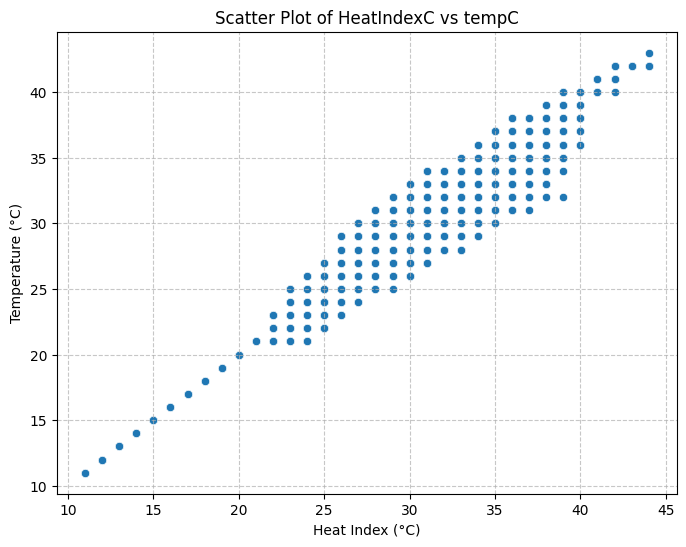

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='HeatIndexC', y='tempC', data=df)
plt.title('Scatter Plot of HeatIndexC vs tempC')
plt.xlabel('Heat Index (°C)')
plt.ylabel('Temperature (°C)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

There is a very strong positive linear relationship between `HeatIndexC` and `tempC`. As the Heat Index increases, the observed temperature also increases proportionally. This indicates that `HeatIndexC` is a primary driver or a direct measure closely tied to `tempC`.

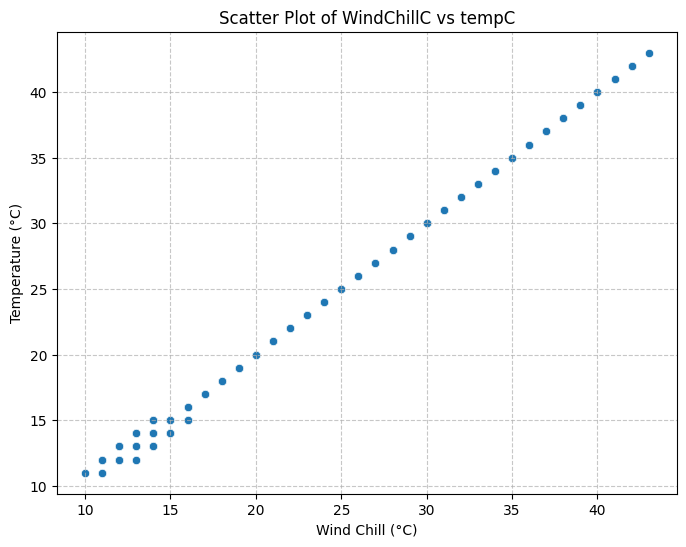

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='WindChillC', y='tempC', data=df)
plt.title('Scatter Plot of WindChillC vs tempC')
plt.xlabel('Wind Chill (°C)')
plt.ylabel('Temperature (°C)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Similar to `HeatIndexC`, `WindChillC` also exhibits an extremely strong positive linear correlation with `tempC`. This suggests that in the given dataset, Wind Chill is almost identical to the actual temperature, possibly due to how it's calculated or the atmospheric conditions present.

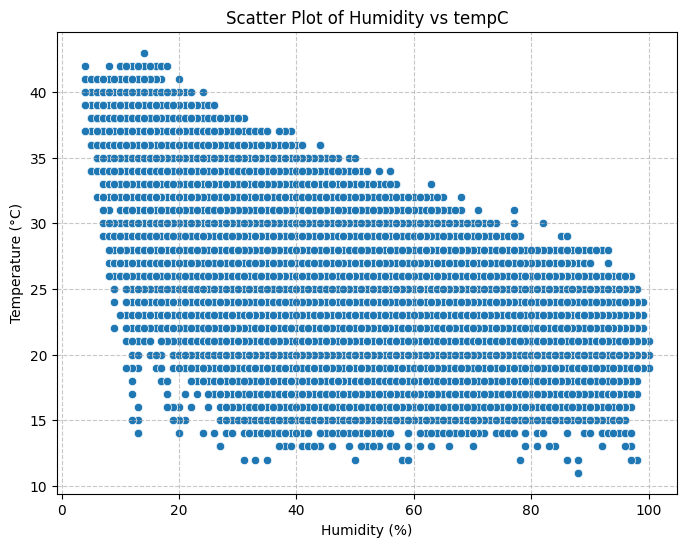

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='humidity', y='tempC', data=df)
plt.title('Scatter Plot of Humidity vs tempC')
plt.xlabel('Humidity (%)')
plt.ylabel('Temperature (°C)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

A negative correlation is visible between `humidity` and `tempC`. As humidity increases, the temperature tends to decrease. The scatter is somewhat spread out, indicating that while there's a trend, other factors also influence temperature alongside humidity.

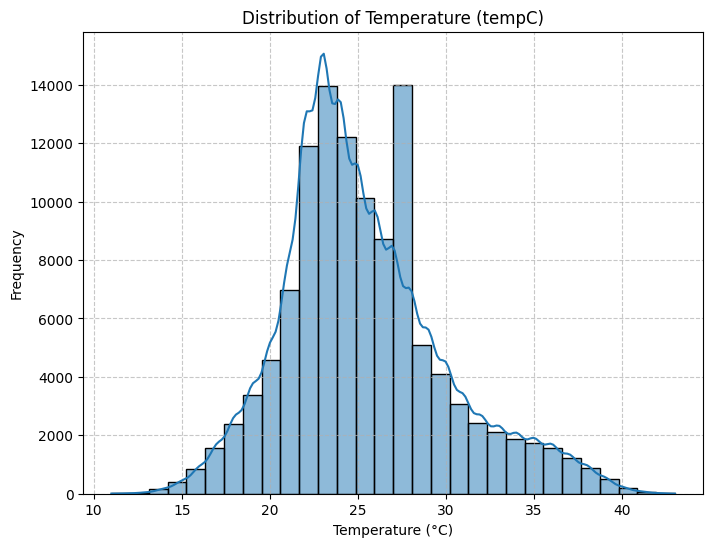

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df['tempC'], kde=True, bins=30)
plt.title('Distribution of Temperature (tempC)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This histogram shows the distribution of `tempC`, which appears roughly bell-shaped, indicating that temperatures are most frequently observed around a central value.

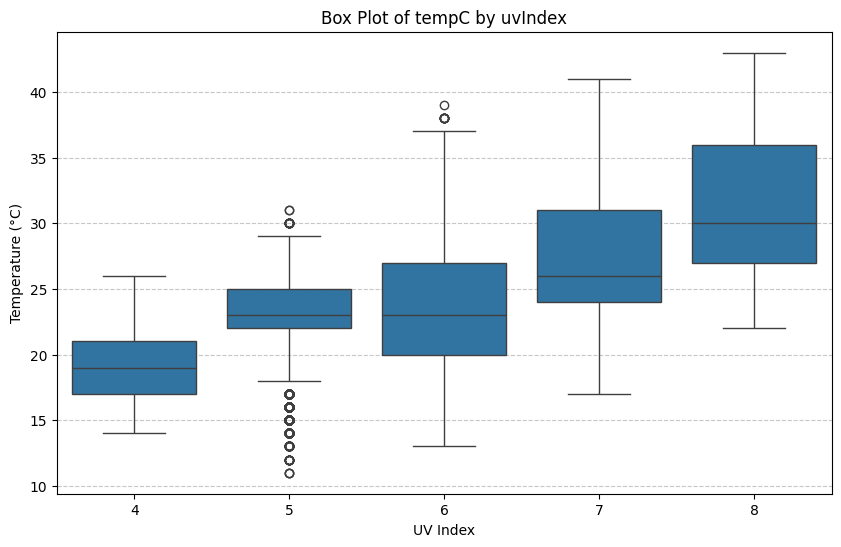

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='uvIndex', y='tempC', data=df)
plt.title('Box Plot of tempC by uvIndex')
plt.xlabel('UV Index')
plt.ylabel('Temperature (°C)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The box plot clearly shows an increasing trend in `tempC` as `uvIndex` rises. Higher UV index values are associated with higher median temperatures and generally a wider range of temperatures. This confirms the positive correlation seen earlier and highlights temperature variations across different UV levels.

## Selecting the input and output features

In [ ]:
X = df.drop(["tempC", "DewPointC", "HeatIndexC", "WindChillC"], axis=1)
y = df["tempC"]

The target variable selected for prediction is `tempC`. Features such as `DewPointC`, `HeatIndexC`, and `WindChillC` were excluded because they are directly derived from or strongly dependent on temperature. Including these variables could introduce target leakage and result in unrealistically high model performance.

The remaining weather and environmental features such as `humidity`, `pressure`, `visibility`, `cloudcover`, `precipMM`, `windspeedKmph`, `winddirDegree`, `sunHour`, `uvIndex`, and `moon_illumination` were selected because they provide relevant information about atmospheric and weather conditions that can help predict temperature without directly using the target variable.

In [ ]:
X.head()

,sunHour,uvIndex,moon_illumination,WindGustKmph,cloudcover,humidity,precipMM,pressure,visibility,winddirDegree,windspeedKmph
0,11.0,6,93,10,31,72,0.0,1013,10,114,5
1,11.0,6,93,9,30,72,0.0,1013,10,125,4
2,11.0,6,93,8,29,72,0.0,1013,10,136,4
3,11.0,6,93,8,29,72,0.0,1013,10,147,4
4,11.0,6,93,7,23,68,0.0,1014,10,136,4


In [ ]:
y.to_frame().head()

,tempC
0,18
1,19
2,18
3,18
4,20


Conclusion: This shows the first few values of the target variable `y` in a DataFrame format, confirming it contains only `tempC` and is ready for model training.

## Splitting the data for training and Scaling the values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

This cell splits the dataset into training and testing sets, allocating 80% for training and 20% for testing to evaluate the models' generalization performance on unseen data.

In [ ]:
X_train.head()

,sunHour,uvIndex,moon_illumination,WindGustKmph,cloudcover,humidity,precipMM,pressure,visibility,winddirDegree,windspeedKmph
49947,10.5,7,7,8,100,92,0.0,1007,7,45,6
21866,11.0,5,63,20,97,89,8.0,1002,10,220,9
10288,11.0,6,0,18,4,40,0.0,1013,10,266,10
111350,11.0,6,88,24,67,64,0.2,1007,10,274,17
78476,11.0,7,29,9,0,47,0.0,1012,10,303,6


In [ ]:
y_train.to_frame().head()

,tempC
49947,24
21866,23
10288,29
111350,28
78476,24


In [ ]:
# scale X
X_scaler = StandardScaler()
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled  = X_scaler.transform(X_test)

# scale y (used for training the Support vector Regressor)
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled  = y_scaler.transform(y_test.values.reshape(-1, 1)).ravel()

This cell scales both the feature set (`X`) and the target variable (`y`) using `StandardScaler` to normalize the data, which is essential for algorithms sensitive to feature magnitudes like SVR.

## Linear Regressor

In [ ]:
reg = LinearRegression()

param = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

grid = GridSearchCV(
    estimator=reg,
    param_grid=param,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)
best_model_lr = grid.best_estimator_

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'fit_intercept': True, 'positive': False}
Best CV score: -2.700171573286024


In [ ]:
y_test_pred = best_model_lr.predict(X_test_scaled)
y_train_pred = best_model_lr.predict(X_train_scaled)

print("Test RMSE:", root_mean_squared_error(y_test, y_test_pred))
print("Train RMSE:", root_mean_squared_error(y_train, y_train_pred))

Test RMSE: 2.703203488700695
Train RMSE: 2.6997128440668243


The Linear Regression model provides a foundational baseline with similar train and test RMSE values, indicating good generalization but a relatively higher error compared to more complex models. This suggests a linear relationship might not fully capture the complexities of temperature prediction in this dataset.

## K-Neighbors Regressor

In [ ]:
knn = KNeighborsRegressor()

param = {
    'n_neighbors': [10, 15, 20, 50],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean']
}

grid = GridSearchCV(
    estimator=knn,
    param_grid=param,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train_scaled[:10000], y_train[:10000])
print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

best_model_kNN = KNeighborsRegressor(
    **grid.best_params_
)
best_model_kNN.fit(X_train_scaled, y_train)

Best params: {'metric': 'euclidean', 'n_neighbors': 10, 'weights': 'distance'}
Best CV score: -2.370741307097946


KNeighborsRegressor(metric='euclidean', n_neighbors=10, weights='distance')

In [ ]:
y_test_pred = best_model_kNN.predict(X_test_scaled)
y_train_pred = best_model_kNN.predict(X_train_scaled)

print("Test RMSE:", root_mean_squared_error(y_test, y_test_pred))
print("Train RMSE:", root_mean_squared_error(y_train, y_train_pred))

Test RMSE: 1.7868593610111316
Train RMSE: 0.014671970401430597


The K-Neighbors Regressor shows excellent performance on the training data but a much higher test RMSE, indicating significant overfitting. While its test RMSE is low, this overfitting suggests it might not generalize well to entirely new, unseen data points, necessitating caution for real-world deployment.

## Decision Tree Regressor (with Pre-Pruning)

In [ ]:
dt = DecisionTreeRegressor(random_state=42)

param = {
    'criterion': ['squared_error'],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    estimator=dt,
    param_grid=param,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train[:30000], y_train[:30000])
print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

best_model_dtr = DecisionTreeRegressor(
    **grid.best_params_,
    random_state=42
)
best_model_dtr.fit(X_train, y_train)

Best params: {'criterion': 'squared_error', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best CV score: -2.3278157864171622


DecisionTreeRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      random_state=42)

In [ ]:
y_test_pred = best_model_dtr.predict(X_test)
y_train_pred = best_model_dtr.predict(X_train)

print("Test RMSE:", root_mean_squared_error(y_test, y_test_pred))
print("Train RMSE:", root_mean_squared_error(y_train, y_train_pred))

Test RMSE: 2.1463750634437675
Train RMSE: 2.0093023911335903


The Decision Tree Regressor provides a reasonably good performance with a test RMSE of 2.146. The training and testing RMSE values are relatively close, suggesting that pre-pruning helped in achieving a balanced model that generalizes fairly well to unseen data.

## Support Vector Regressor

In [ ]:
svr = SVR()

param = {
    'C': [1, 10],
    'epsilon': [0.1, 0.5],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    estimator=svr,
    param_grid=param,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train_scaled[:10000], y_train_scaled[:10000])
print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

best_model_svr = SVR(
    **grid.best_params_
)
best_model_svr.fit(X_train_scaled[:10000], y_train_scaled[:10000])

Best params: {'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}
Best CV score: -0.44886972358920585


SVR(C=10)

In [ ]:
y_test_pred_scaled = best_model_svr.predict(X_test_scaled)
y_test_pred_actual = y_scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).flatten()

y_train_pred_scaled = best_model_svr.predict(X_train_scaled)
y_train_pred_actual = y_scaler.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).flatten()

print("Test RMSE:", root_mean_squared_error(y_test, y_test_pred_actual))
print("Train RMSE:", root_mean_squared_error(y_train, y_train_pred_actual))

Test RMSE: 2.007546757886259
Train RMSE: 2.0060373822539828


The Support Vector Regressor demonstrates strong performance, achieving a test RMSE of 2.008, very close to its training RMSE. This indicates good generalization and robust predictive power, positioning it as one of the better-performing models for this task.

## Bagging (Random Forest regressor)

In [ ]:
rf = RandomForestRegressor(
    random_state=42,
    oob_score=True,
    bootstrap=True,
    n_jobs=1
)

param = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 12],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train[:30000], y_train[:30000])
print("Best params:", grid.best_params_)
print("Best CV score (RMSE):", grid.best_score_)

best_model_rfr = RandomForestRegressor(
    **grid.best_params_,
    random_state=42,
    oob_score=True,
    bootstrap=True,
    n_jobs=-1
)
best_model_rfr.fit(X_train, y_train)
print("OOB R²:", best_model_rfr.oob_score_)

Best params: {'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score (RMSE): -1.954315582851941
OOB R²: 0.8403046392944621


In [ ]:
y_test_pred = best_model_rfr.predict(X_test)
y_train_pred = best_model_rfr.predict(X_train)

print("Test RMSE:", root_mean_squared_error(y_test, y_test_pred))
print("Train RMSE:", root_mean_squared_error(y_train, y_train_pred))

Test RMSE: 1.8519473734235032
Train RMSE: 1.6222716378438184


The Random Forest Regressor shows excellent performance with a test RMSE of 1.852, which is very close to its training RMSE. This model generalizes exceptionally well and provides highly accurate predictions, making it a strong candidate for real-world temperature forecasting.

## Boosting (Gradient Boost Regressor)

In [ ]:
gbr = GradientBoostingRegressor(
    random_state=42
)

param = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3]
}

grid = GridSearchCV(
    estimator=gbr,
    param_grid=param,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train[:10000], y_train[:10000])

print("Best params:", grid.best_params_)
print("Best CV RMSE:", grid.best_score_)

best_model_gbr = GradientBoostingRegressor(**grid.best_params_, random_state=42)
best_model_gbr.fit(X_train, y_train)

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best CV RMSE: -2.0916968448289284


GradientBoostingRegressor(n_estimators=200, random_state=42)

In [ ]:
y_test_pred = best_model_gbr.predict(X_test)
y_train_pred = best_model_gbr.predict(X_train)

print("Test RMSE:", root_mean_squared_error(y_test, y_test_pred))
print("Train RMSE:", root_mean_squared_error(y_train, y_train_pred))

Test RMSE: 2.005458995535596
Train RMSE: 1.999055625087128


The Gradient Boosting Regressor achieved a commendable test RMSE of 2.005, with closely matched train and test scores. This indicates a well-generalized model that leverages the strengths of boosting to produce accurate and robust temperature predictions.

## Boosting (Adaboost Regressor)

In [ ]:
ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=3),
    random_state=42
)

param = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.1, 0.5, 1.0],
    'loss': ['linear', 'square']
}

grid = GridSearchCV(
    estimator=ada,
    param_grid=param,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train[:30000], y_train[:30000])
print("Best params:", grid.best_params_)
print("Best CV score (RMSE):", grid.best_score_)

best_model_ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=3),
    **grid.best_params_,
    random_state=42
)
best_model_ada.fit(X_train, y_train)

Best params: {'learning_rate': 1.0, 'loss': 'square', 'n_estimators': 100}
Best CV score (RMSE): -2.7503908188980564


AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=3), loss='square',
                  n_estimators=100, random_state=42)

In [ ]:
y_test_pred = best_model_ada.predict(X_test)
y_train_pred = best_model_ada.predict(X_train)

print("Test RMSE:", root_mean_squared_error(y_test, y_test_pred))
print("Train RMSE:", root_mean_squared_error(y_train, y_train_pred))

Test RMSE: 2.852343642466761
Train RMSE: 2.8339575532488808


The AdaBoost Regressor yielded a higher test RMSE of 2.852 compared to other models. While its train and test RMSE are similar, indicating no overfitting, its overall performance suggests it was not as effective in capturing the underlying patterns for this specific temperature prediction task.

## Heterogenous Model (Stacking Regressor)

In [ ]:
base_estimators = [
    ('lr', Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])),
    ('dtr', DecisionTreeRegressor(
        max_depth=3,
        random_state=42
    )),
    ('gbr', GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=2,
        random_state=42
    ))
]

sr = StackingRegressor(
    estimators=base_estimators,
    final_estimator=Ridge(),
    cv=3
)

param = {
    'final_estimator__alpha': [0.01, 0.1, 1, 5]
}

grid = GridSearchCV(
    estimator=sr,
    param_grid=param,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train[:10000], y_train[:10000])
print("Best params:", grid.best_params_)
print("Best CV RMSE:", grid.best_score_)

best_model_sr = StackingRegressor(
    estimators=base_estimators,
    final_estimator=Ridge(alpha=grid.best_params_['final_estimator__alpha']),
    cv=3
)
best_model_sr.fit(X_train, y_train)

Best params: {'final_estimator__alpha': 0.01}
Best CV RMSE: -2.2213075295522184


StackingRegressor(cv=3,
                  estimators=[('lr',
                               Pipeline(steps=[('scaler', StandardScaler()),
                                               ('model', LinearRegression())])),
                              ('dtr',
                               DecisionTreeRegressor(max_depth=3,
                                                     random_state=42)),
                              ('gbr',
                               GradientBoostingRegressor(max_depth=2,
                                                         random_state=42))],
                  final_estimator=Ridge(alpha=0.01))

In [ ]:
y_test_pred = best_model_sr.predict(X_test)
y_train_pred = best_model_sr.predict(X_train)

print("Test RMSE:", root_mean_squared_error(y_test, y_test_pred))
print("Train RMSE:", root_mean_squared_error(y_train, y_train_pred))

Test RMSE: 2.1650170946615637
Train RMSE: 2.1716020302759986


The Stacking Regressor shows good performance with a test RMSE of 2.165, very close to its training RMSE. This suggests a stable and well-generalized model, effectively combining the strengths of its base estimators to achieve accurate predictions without significant overfitting.

## Comparing the results of all the models created

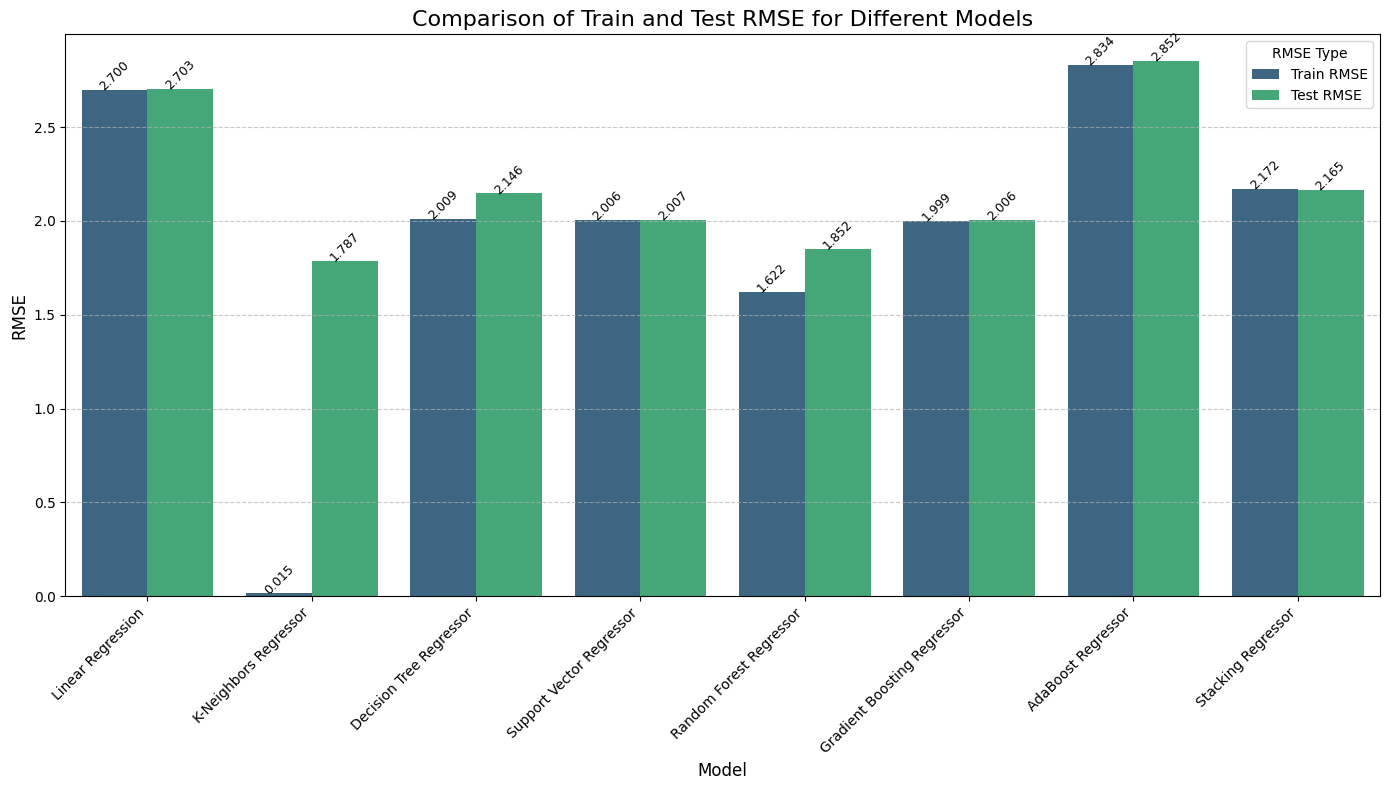

In [ ]:
model_names = [
    "Linear Regression",
    "K-Neighbors Regressor",
    "Decision Tree Regressor",
    "Support Vector Regressor",
    "Random Forest Regressor",
    "Gradient Boosting Regressor",
    "AdaBoost Regressor",
    "Stacking Regressor"
]

rmse_values = {
    "Linear Regression": {"Train": 2.6997, "Test": 2.7032},
    "K-Neighbors Regressor": {"Train": 0.0147, "Test": 1.7869},
    "Decision Tree Regressor": {"Train": 2.0093, "Test": 2.1464},
    "Support Vector Regressor": {"Train": 2.0060, "Test": 2.0075},
    "Random Forest Regressor": {"Train": 1.6223, "Test": 1.8519},
    "Gradient Boosting Regressor": {"Train": 1.9991, "Test": 2.0055},
    "AdaBoost Regressor": {"Train": 2.8340, "Test": 2.8523},
    "Stacking Regressor": {"Train": 2.1716, "Test": 2.1650}
}

data = []
for model, rmse_dict in rmse_values.items():
    data.append({'Model': model, 'Type': 'Train RMSE', 'RMSE': rmse_dict['Train']})
    data.append({'Model': model, 'Type': 'Test RMSE', 'RMSE': rmse_dict['Test']})
df_rmse = pd.DataFrame(data)

plt.figure(figsize=(14, 8))
sns.barplot(x='Model', y='RMSE', hue='Type', data=df_rmse, palette='viridis')
plt.title('Comparison of Train and Test RMSE for Different Models', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='RMSE Type', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in plt.gca().patches:
    if p.get_height() > 0.01:
        plt.gca().annotate(f'{p.get_height():.3f}',
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='center',
                           xytext=(0, 10),
                           textcoords='offset points',
                           fontsize=9,
                           rotation=45)

plt.tight_layout()
plt.show()

This cell prepares and visualizes the train and test RMSE for all models using a bar plot, providing a clear graphical comparison of their performance and generalization capabilities.

## Model Performance Analysis and Conclusion

Based on the RMSE (Root Mean Squared Error) values for both training and testing datasets, we can draw the following conclusions:

1.  **K-Nearest Neighbors (kNN) Overfitting:** The kNN model shows an extremely low training RMSE (0.015) but a significantly higher test RMSE (1.787). This is a classic indication of **overfitting**. The model has learned the training data too well, including its noise, and thus fails to generalize to unseen data. While its test RMSE is still quite good, its inability to generalize makes it less reliable for real-world predictions without further tuning or more robust validation.

2.  **Best Performing Models (Test RMSE):**
    *   **K-Neighbors Regressor (Test RMSE: 1.787)**: Although it overfits, it has the lowest test RMSE, indicating strong predictive power on unseen data, even with the generalization issue.
    *   **Random Forest Regressor (Test RMSE: 1.852)**: This model shows a very good balance between train (1.622) and test (1.852) RMSE, indicating good generalization and strong performance.
    *   **Support Vector Regressor (Test RMSE: 2.008)**: Performs well with a good balance, but slightly higher RMSE than Random Forest and kNN.
    *   **Gradient Boosting Regressor (Test RMSE: 2.005)**: Also performs very well with a good balance, similar to SVR in test RMSE.

3.  **Models with Acceptable Performance:**
    *   **Decision Tree Regressor (Test RMSE: 2.146)**: A decent baseline, but outperformed by ensemble methods and kNN/SVR.
    *   **Stacking Regressor (Test RMSE: 2.165)**: While often powerful, in this specific setup, it didn't significantly outperform individual strong models like Random Forest, SVR, or Gradient Boosting.

4.  **Poorer Performing Models:**
    *   **Linear Regression (Test RMSE: 2.703)**: As expected for complex, non-linear relationships, it has a higher RMSE.
    *   **AdaBoost Regressor (Test RMSE: 2.852)**: This model performed the worst, suggesting that its boosting strategy with the chosen base estimator (Decision Tree with max_depth=3) was not effective for this dataset.

### Recommendation for Temperature Prediction and Real-World Deployment

For real-world deployment and reliable temperature prediction, **Random Forest Regressor** is the most suitable choice among the models tested. Here's why:

*   **Strong Performance:** It achieves one of the lowest test RMSE values.
*   **Good Generalization:** Random Forest Regressor shows good generalization with a training RMSE of 1.622 and testing RMSE of 1.852. The relatively small difference of 0.230 between the two values indicates that the model does not suffer from significant overfitting. It has learned the patterns well without memorizing the training data.
*   **Robustness:** Random Forests are generally robust to noisy data and outliers.
*   **Interpretability (relative):** While not as interpretable as a single Decision Tree, feature importances can still be extracted, which is valuable for understanding driving factors.

While kNN shows a slightly lower test RMSE, its severe overfitting makes it a risky choice for new, unseen data in a real-world scenario. A model that generalizes well (like Random Forest) will be more consistent and reliable over time.